In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
batch_size = 128

In [ ]:
# Transform: normalize images between [-1, 1] (because Tanh will be used at output)
transform = transforms.Compose([
    transforms.ToTensor(), # converts numpy to torch, HxWxC -> CxHxW, [0,255] -> [0,1]
    transforms.Normalize((0.5,), (0.5,)) # x - mu / sigma [-1,1]
])

# Load MNIST
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.67MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim):
        super().__init__()

        self.z_dim = z_dim
        self.x_dim = x_dim

        self.model = nn.Sequential(
            nn.Linear(self.z_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, self.x_dim),
            nn.Tanh()  # Because we normalized images to [-1, 1]
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, x_dim):
        super().__init__()

        self.x_dim = x_dim

        self.model = nn.Sequential(
            nn.Linear(self.x_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Outputs probability between 0 and 1
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
z_dim = 100
x_dim = 28 * 28

# Models
generator     = Generator(z_dim, x_dim).to(device)
discriminator = Discriminator(x_dim).to(device)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

# Loss
bce_loss = nn.BCELoss()

In [ ]:
def show_generated_images(epoch, generator, z):
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(z).reshape(-1, 1, 28, 28)
        fake_imgs = fake_imgs * 0.5 + 0.5  # De-normalize

    grid = torchvision.utils.make_grid(fake_imgs, nrow=8)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f'Generated Images at Epoch {epoch}')
    plt.axis('off')
    plt.show()
    generator.train()

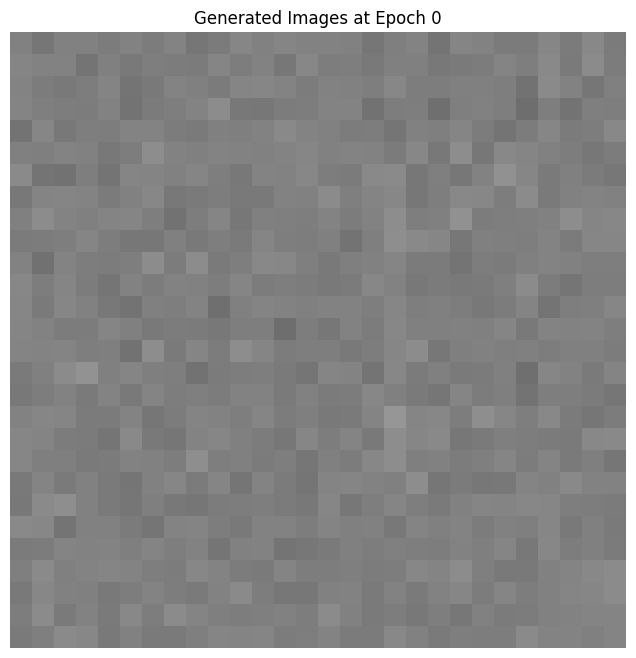

In [ ]:
z = torch.randn(z_dim).to(device)
show_generated_images(0, generator, z)

In [ ]:
img, label = next(iter(train_loader))
# print(idx)
print(img.shape)
print(label)

torch.Size([128, 1, 28, 28])
tensor([1, 6, 7, 2, 8, 6, 7, 0, 9, 2, 7, 6, 5, 8, 6, 7, 1, 5, 6, 6, 6, 8, 4, 1,
        8, 4, 9, 7, 0, 8, 9, 4, 8, 0, 3, 7, 5, 8, 9, 4, 0, 4, 4, 3, 1, 4, 4, 6,
        5, 4, 6, 3, 8, 2, 1, 2, 2, 3, 3, 7, 7, 1, 3, 3, 9, 4, 0, 7, 1, 0, 9, 5,
        1, 6, 4, 3, 3, 5, 8, 5, 4, 1, 3, 5, 7, 0, 1, 8, 2, 8, 9, 4, 9, 2, 8, 6,
        1, 1, 7, 4, 7, 2, 0, 5, 0, 6, 3, 7, 6, 2, 7, 2, 6, 8, 7, 9, 6, 3, 6, 9,
        7, 4, 2, 3, 2, 6, 6, 2])


In [ ]:
def train_gan(train_loader, num_epochs, mode="one_one"):

    for epoch in range(num_epochs):
        for batch_idx, (X, _Y) in enumerate(train_loader):
            X = X.view(batch_size, -1).to(device) # Flattens from (B, C, H, W) -> (B, C x H x W)

            # Create real and fake labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            ## 1. Train Discriminator

            # Real images
            Dw_x = discriminator(X)
            d_loss_real = bce_loss(Dw_x, real_labels)

            # Fake images
            z = torch.randn(batch_size, z_dim).to(device)
            g_theta_z = generator(z)
            Dw_g_theta_z = discriminator(g_theta_z.detach())  # detach so gradients don't flow into generator
            d_loss_fake = bce_loss(Dw_g_theta_z, fake_labels)

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

            discriminator.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            ## 2. Train Generator

            # Generate fake images again
            z = torch.randn(batch_size, z_dim).to(device)
            g_theta_z = generator(z)
            Dw_g_theta_z = discriminator(g_theta_z)

            g_loss = bce_loss(Dw_g_theta_z, real_labels)  # trick discriminator
            # g_loss = bce_loss(Dw_g_theta_z, fake_labels) # actual g_loss(to use this, - on optimizer)

            generator.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            ## 3. Modify according to mode

            if mode == "five_gen_one_disc":
                for _ in range(4):  # already did 1 step above
                    z = torch.randn(batch_size, z_dim).to(device)
                    g_theta_z = generator(z)
                    Dw_g_theta_z = discriminator(g_theta_z)
                    g_loss = bce_loss(Dw_g_theta_z, real_labels)

                    generator.zero_grad()
                    g_loss.backward()
                    g_optimizer.step()

            if mode == "five_disc_one_gen":
                for _ in range(4):  # already did 1 step above
                    # Real
                    Dw_x = discriminator(X)
                    d_loss_real = bce_loss(Dw_x, real_labels)

                    # Fake
                    z = torch.randn(batch_size, z_dim).to(device)
                    g_theta_z = generator(z)
                    Dw_g_theta_z = discriminator(g_theta_z.detach())
                    d_loss_fake = bce_loss(Dw_g_theta_z, fake_labels)

                    d_loss = d_loss_real + d_loss_fake

                    discriminator.zero_grad()
                    d_loss.backward()
                    d_optimizer.step()

        if (epoch+1) % 10 == 0:
            fixed_noise = torch.randn(batch_size, z_dim).to(device)  # For consistent visualization
            print(f"Epoch [{epoch+1}/{num_epochs}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}")
            show_generated_images(epoch+1, generator, fixed_noise)

Training: 1-step Gen, 1-step Disc
Epoch [10/50], D_loss: 0.8423, G_loss: 2.4586


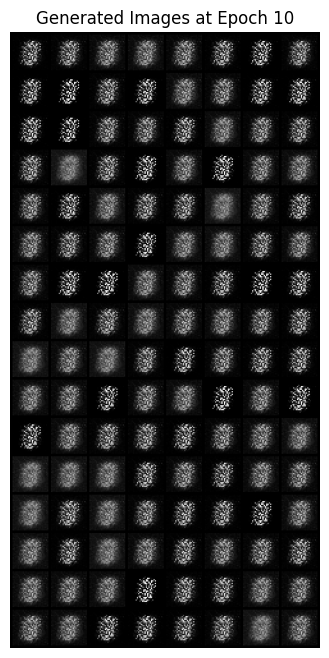

Epoch [20/50], D_loss: 0.5545, G_loss: 2.8941


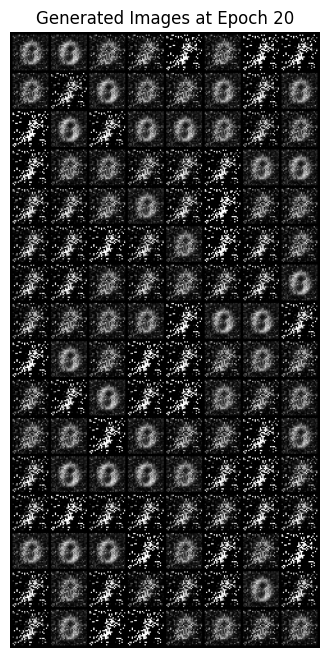

Epoch [30/50], D_loss: 0.3424, G_loss: 4.5941


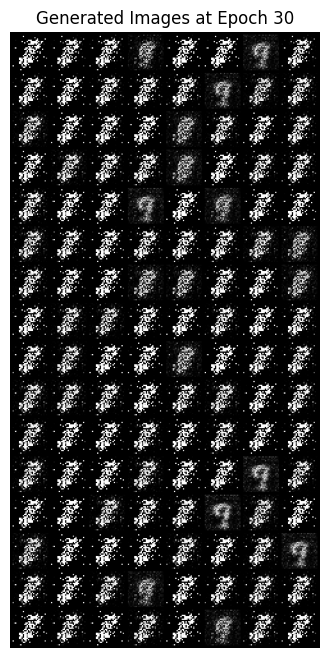

Epoch [40/50], D_loss: 0.7945, G_loss: 3.9393


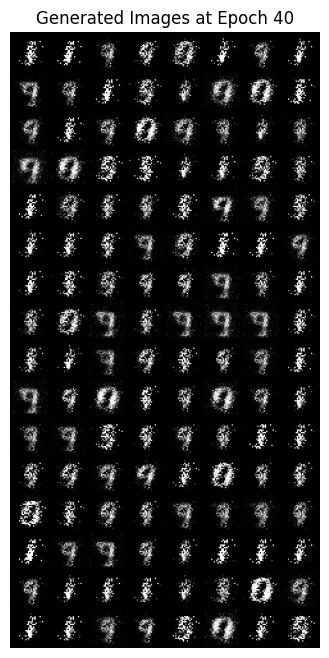

Epoch [50/50], D_loss: 0.4356, G_loss: 2.7523


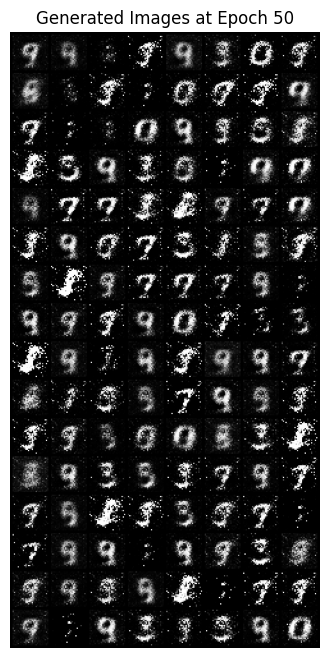

Training: 5-step Gen, 1-step Disc
Epoch [10/50], D_loss: 0.0004, G_loss: 8.0653


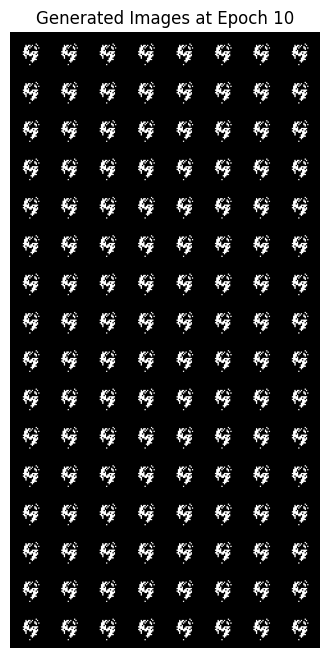

Epoch [20/50], D_loss: 0.0000, G_loss: 11.7076


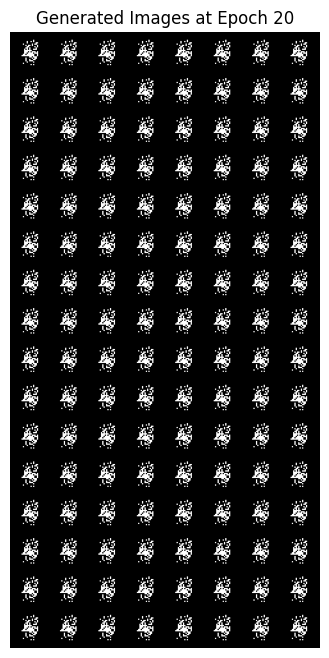

Epoch [30/50], D_loss: 0.0000, G_loss: 14.9909


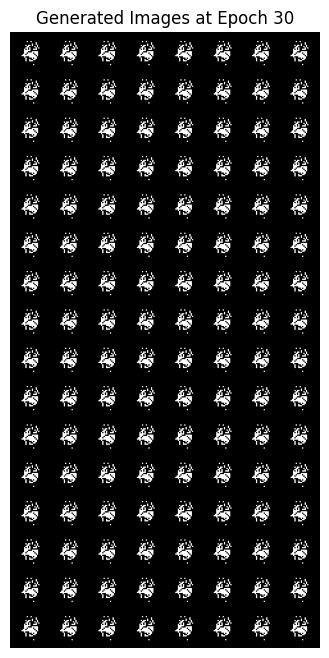

Epoch [40/50], D_loss: 0.0000, G_loss: 17.3367


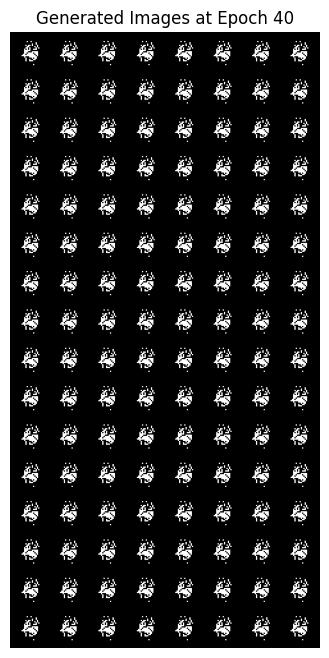

Epoch [50/50], D_loss: 0.0000, G_loss: 19.9463


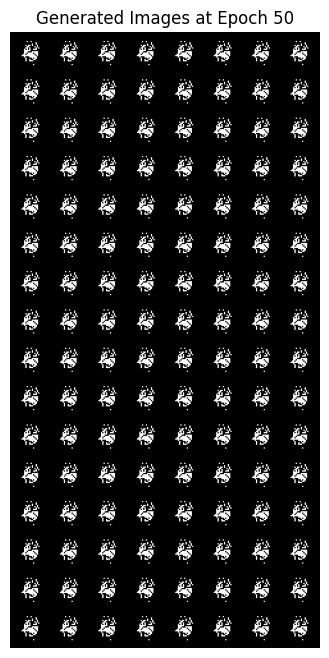

Training: 5-step Disc, 1-step Gen
Epoch [10/50], D_loss: 0.0000, G_loss: 28.1483


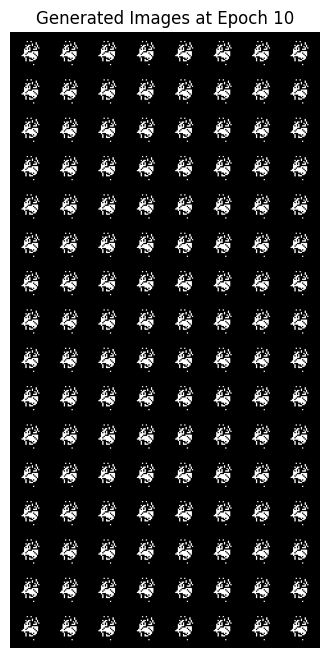

Epoch [20/50], D_loss: 0.0000, G_loss: 28.8661


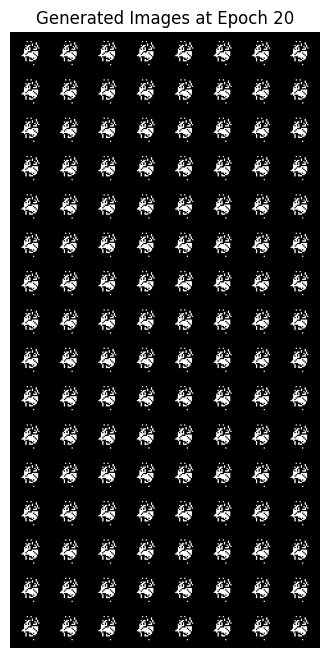

Epoch [30/50], D_loss: 0.0000, G_loss: 29.2573


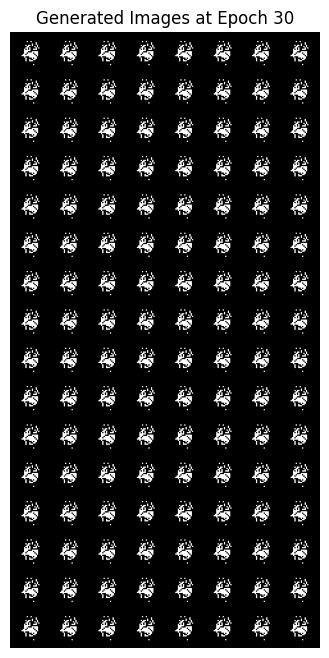

Epoch [40/50], D_loss: 0.0000, G_loss: 29.3298


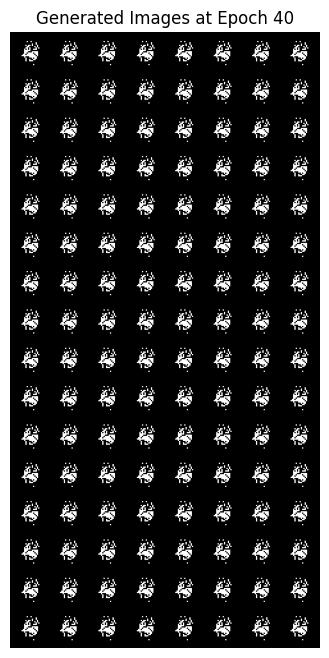

Epoch [50/50], D_loss: 0.0000, G_loss: 29.5160


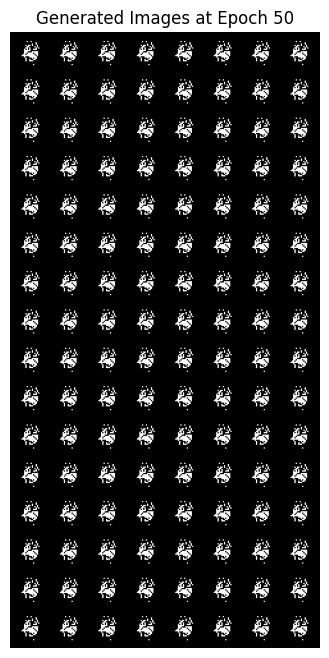

In [ ]:
# 1. Standard: One step Generator, One step Discriminator
print("Training: 1-step Gen, 1-step Disc")
train_gan(train_loader, num_epochs=50, mode="one_one")

# 2. 5 Generator steps, 1 Discriminator step
print("Training: 5-step Gen, 1-step Disc")
train_gan(train_loader, num_epochs=50, mode="five_gen_one_disc")

# 3. 5 Discriminator steps, 1 Generator step
print("Training: 5-step Disc, 1-step Gen")
train_gan(train_loader, num_epochs=50, mode="five_disc_one_gen")